# <div style="font-family: Trebuchet MS; background-color: #176BA0; color: #FFFFFF; padding: 12px; line-height: 1.5;">   Метод муравьиной колонии (Feature Selection)</div>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as md
%matplotlib inline
plt.style.use('bmh'); sns.set_style("whitegrid")
plt.rc('xtick', labelsize=15); plt.rc('ytick', labelsize=15) 
import warnings
warnings.simplefilter(action='ignore')

df = pd.read_pickle("samples.pkl")  

FEATURES, TARGET = [ 'in_CU', 'in_FE', 'in_NI', 
             'Speed_2', 'Speed_4', 'Speed_6', 'Speed_8', 
             'Lvl 2 setpoint', 'Lvl 4 setpoint', 'Lvl 6 setpoint', 'Lvl 8 setpoint', 
              'Air 3', 'Tok 3', 'Air 4', 'Tok 4', ], 'TailCU'

df = df[[TARGET,] + FEATURES]

## Старт EDA

In [2]:
df.head()

,TailCU,in_CU,in_FE,in_NI,Speed_2,Speed_4,Speed_6,Speed_8,Lvl 2 setpoint,Lvl 4 setpoint,Lvl 6 setpoint,Lvl 8 setpoint,Air 3,Tok 3,Air 4,Tok 4
DateInsert,,,,,,,,,,,,,,,,
2022-05-23 19:53:00,0.898075,13.919510,32.345389,4.815450,107.922391,136.144128,142.539069,154.857885,-806.527490,-651.646863,-510.624677,-390.624371,15.949063,252.559999,16.006042,236.338661
2022-05-23 20:09:00,0.867257,19.689948,37.300351,5.219653,99.240810,133.522113,146.358502,153.957974,-818.547192,-650.765637,-519.263751,-395.480621,16.064687,249.069336,15.922396,234.695996
2022-05-23 20:24:00,0.929501,20.363113,36.694915,5.195581,109.142298,129.228968,147.776832,156.357753,-824.021570,-665.718750,-516.819983,-391.737189,16.029271,255.640002,15.991250,235.722662
2022-05-23 20:39:00,0.862103,20.349568,37.043935,5.136996,95.270122,138.226527,25.296272,164.205829,-819.400610,-670.809387,-494.418445,-376.719373,16.040417,256.666670,15.918750,236.133327
2022-05-23 20:54:00,0.916710,20.605583,36.730388,5.106030,113.091316,124.107429,-2.511736,173.441390,-763.117493,-660.009351,-504.745935,-354.291565,16.017396,259.336006,16.044167,238.186659


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 27856 entries, 2022-05-23 19:53:00 to 2023-03-10 17:39:00
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   TailCU          27194 non-null  float64
 1   in_CU           27194 non-null  float64
 2   in_FE           27194 non-null  float64
 3   in_NI           27194 non-null  float64
 4   Speed_2         27800 non-null  float64
 5   Speed_4         27788 non-null  float64
 6   Speed_6         27792 non-null  float64
 7   Speed_8         27797 non-null  float64
 8   Lvl 2 setpoint  27799 non-null  float64
 9   Lvl 4 setpoint  27792 non-null  float64
 10  Lvl 6 setpoint  27802 non-null  float64
 11  Lvl 8 setpoint  27797 non-null  float64
 12  Air 3           27780 non-null  float64
 13  Tok 3           27790 non-null  float64
 14  Air 4           27793 non-null  float64
 15  Tok 4           27780 non-null  float64
dtypes: float64(16)
memory usage: 3.6 MB


In [4]:
df.describe()

,TailCU,in_CU,in_FE,in_NI,Speed_2,Speed_4,Speed_6,Speed_8,Lvl 2 setpoint,Lvl 4 setpoint,Lvl 6 setpoint,Lvl 8 setpoint,Air 3,Tok 3,Air 4,Tok 4
count,27194.000000,27194.000000,27194.000000,27194.000000,27800.000000,27788.000000,27792.000000,27797.000000,27799.000000,27792.000000,27802.000000,27797.000000,27780.000000,27790.000000,27793.000000,27780.000000
mean,1.130214,13.763418,37.922558,3.017976,128.813345,71.298381,59.743340,161.598908,-915.524692,-893.632260,-733.655831,-500.828620,15.481905,245.045527,15.555967,240.403383
std,0.462167,3.413116,6.788345,0.782119,55.889701,31.500652,42.851557,51.051391,237.030062,250.538335,326.467981,227.289860,3.052876,16.881289,2.383496,15.285609
min,-0.105161,-1.240005,0.000000,0.000000,-2.581883,-27.507374,-20.542888,-27.765612,-1500.000000,-1499.765625,-1499.553149,-1499.765625,0.001146,92.399999,0.854688,100.818664
25%,0.859233,12.315943,38.612813,2.689161,87.687865,52.569194,26.978364,137.796869,-977.744379,-961.373438,-850.957510,-596.844360,15.812786,242.088000,15.897917,237.570658
50%,1.119055,14.073571,39.195438,2.986868,129.830780,67.443255,51.320031,174.310431,-909.383740,-862.410938,-687.469690,-429.344373,15.999479,247.426669,15.998333,242.498667
75%,1.359007,15.731021,39.607408,3.362649,166.754345,85.613909,88.226932,196.121195,-812.360315,-752.191406,-517.934999,-345.579053,16.210937,252.559999,16.064271,247.221335
max,14.058990,32.809714,42.585450,6.586976,332.226301,286.438801,216.514959,284.946754,-59.147187,-32.831250,0.000000,0.000000,31.140937,278.431995,41.510833,277.815993


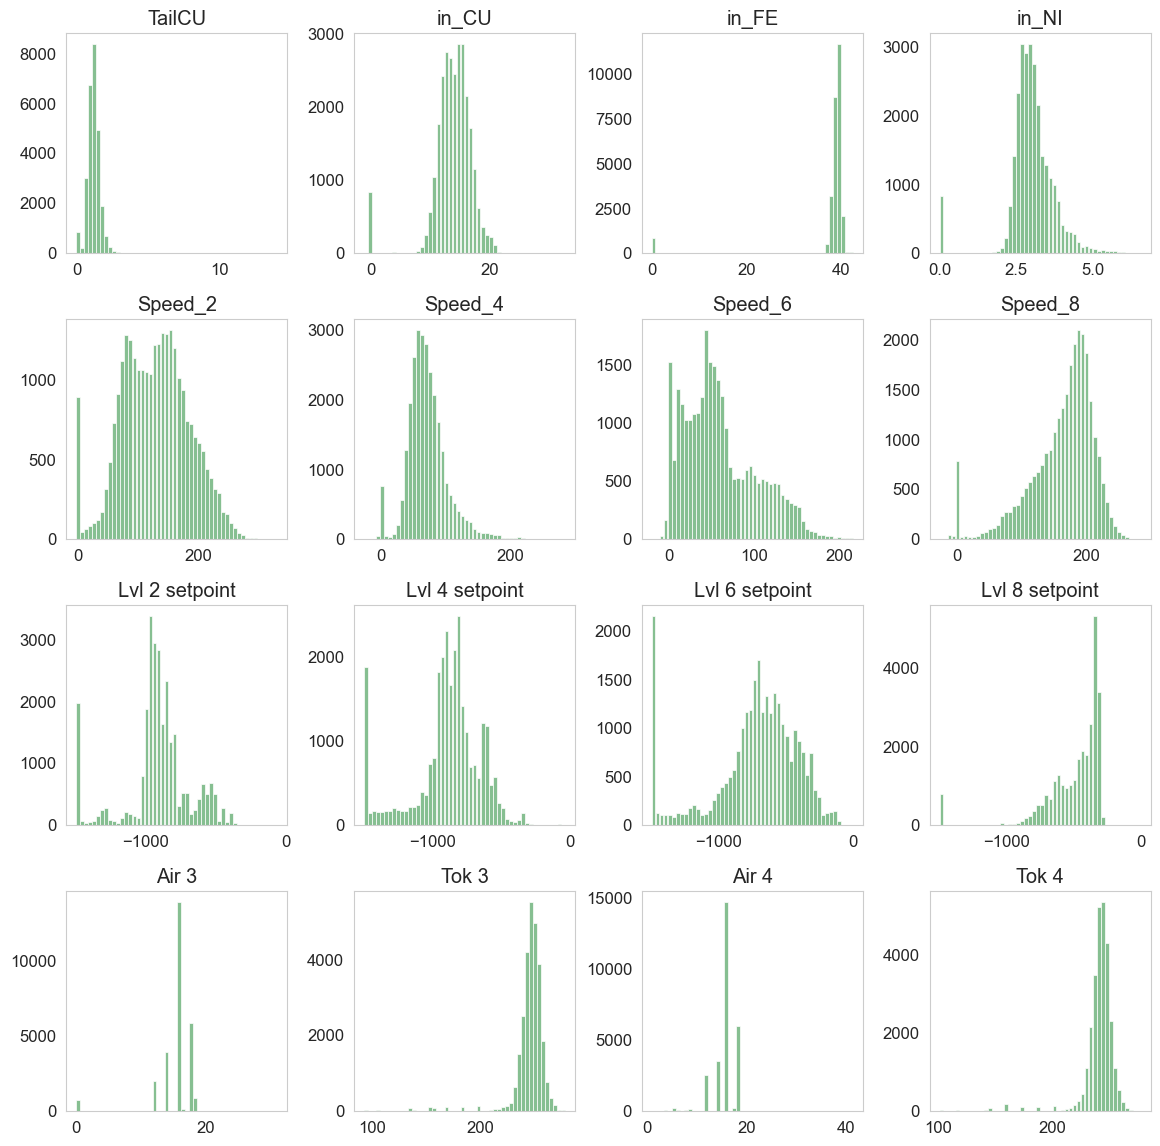

In [5]:
ax = df.hist(bins=50, grid=False, figsize=(14,14), layout=(4,4), color='#86bf91', 
                      zorder=2, rwidth=0.9, xlabelsize=12, ylabelsize=12)

## Уберём строки с нетипичными значениями

In [6]:
from typing import NamedTuple

Rule = NamedTuple("data_limits", [('low_lim', float), ('upper_lim', float)])

preprocessing_rules = dict(
    **{
    'TailCU': Rule(0,5),
    'in_CU':   Rule(5,25),
    'in_FE':   Rule(25, np.nan),
    'in_NI':   Rule(1,6),
    },
    
    **{'Speed_'+str(v): Rule(5,np.nan) for v in (2,4,6,8)},
    **{'Lvl '+str(v)+' setpoint': Rule(-1300,-10) for v in (2,4,6,8)},
    
    **{
    'Air 3':  Rule(2,np.nan), 
    'Air 4':  Rule(2,np.nan), 
    'Tok 3':  Rule(200,np.nan),
    'Tok 4':  Rule(200,np.nan),
    }
)

for f, rule in preprocessing_rules.items():    
    df.loc[(df[f] <= rule.low_lim) | (df[f] >= rule.upper_lim), f] = np.nan
    
print(len(df))
df.dropna(inplace=True)
print(len(df))

27856
21441


In [7]:
df = df[(df.index > '2022-10-01') & (df.index < '2022-12-01')]
print(len(df))

3738


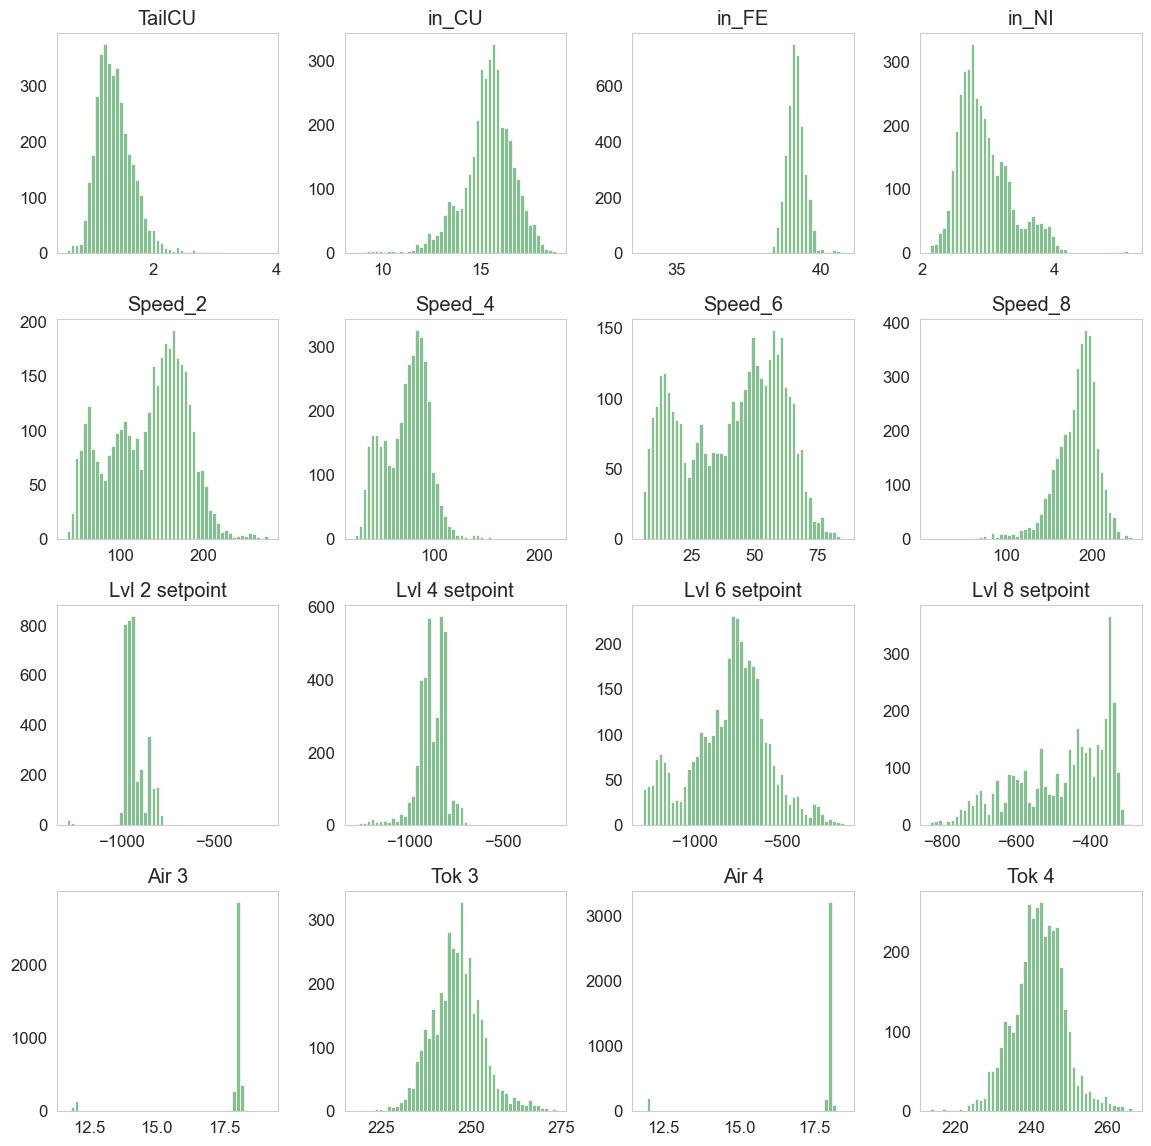

In [8]:
ax = df.hist(bins=50, grid=False, figsize=(14,14), layout=(4,4), color='#86bf91', 
                      zorder=2, rwidth=0.9, xlabelsize=12, ylabelsize=12)

## Сделаем преобразование данных

In [9]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

x_train = df[FEATURES].copy()
y_train = df[TARGET].copy()

x_scaler = MinMaxScaler()
x_scaler.fit(x_train)
x_train = x_scaler.transform(x_train)

all_scaler = MinMaxScaler()
all_scaler.fit(df)
all_scaled = all_scaler.transform(df)
print(df.shape, all_scaled.shape)

(3738, 16) (3738, 16)


### Feature Importance 1. Градиентный бустинг

In [10]:
import pickle
from sklearn import ensemble

params = {
    "n_estimators": 300,
    "max_depth": 4,
    "min_samples_split": 10,
    "learning_rate": 0.01,
    "verbose": 0,#1,
}
model_base_full = ensemble.GradientBoostingRegressor(**params)
model_base_full.fit(x_train, y_train)


GradientBoostingRegressor(learning_rate=0.01, max_depth=4, min_samples_split=10,
                          n_estimators=300)

In [11]:
N_FEATURES = 7

[ 0 10  7 14  8  9  2]


<Axes: xlabel='Vals', ylabel='Name'>

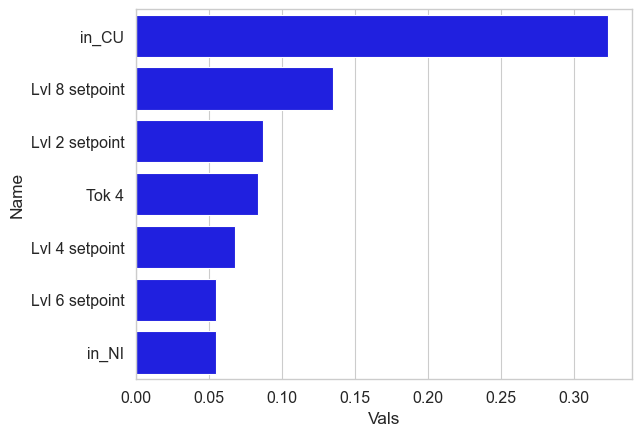

In [12]:
import copy
base_feature_importance = copy.deepcopy(model_base_full.feature_importances_)
base_feature_importance_sorted_idx = np.argsort(base_feature_importance)[::-1]
base_feature_importance_sorted_idx = base_feature_importance_sorted_idx[0:N_FEATURES]
print(base_feature_importance_sorted_idx)

boosting_names = [FEATURES[i] for i in base_feature_importance_sorted_idx]
vals = base_feature_importance[base_feature_importance_sorted_idx]
fimps = pd.DataFrame(data={'Name': boosting_names, 'Vals':vals})

sns.set_context("paper", font_scale=1.3)
sns.barplot(x="Vals", y="Name", data=fimps, label="Total", color="b", )


### Feature Importance 2. Муравьиная колония (UFSACO)

In [13]:
# Малое число
EPS = 1e-6
# Первоначальное число признаков
N_START_FEATURES = all_scaled.shape[1]
print(N_START_FEATURES)
# Итоговое число признаков
N_END_FEATURES = 7
# Максимально число циклов 
NC_MAX = 3
# Число шагов внутри цикла 
N_STEPS = 4
# Начальное количество феромона
INIT_PHEROMONE = 0.2
# коэффициент испарения
RO = 0.2
# Вероятность выполнения шага применения (exploitation)
EXPLOITATION_PROB = 0.7
# Параметры относительной важности некоррелированности выбираемых фичей и коррелированности с таргетом относительно желательности фичи.
ALPHA = 1.0
BETA = 1.0
# Число агентов 
N_ANTS = 5 

16


In [14]:
sim = {}
def set_sim(i, j):
    a = all_scaled[:, i]
    b = all_scaled[:, j]
    res = np.dot(np.asarray(a), np.asarray(b)) / (np.linalg.norm(a) * np.linalg.norm(b))    
    sim[(min(i, j), max(i, j))] = np.abs(res)
    return res

def get_sim(i, j):
    (i, j) = (min(i, j), max(i, j))
    if (i, j) not in sim.keys():
        set_sim(i, j)
    return sim[(i, j)]
  




Цикл по этапам перераспределения: count = 0;NC_MAX=3:

    ants_pos = np.random.choice(N_START_FEATURES, size=N_ANTS, p=tau/sum(tau)) # tau - ферромон

    nodes_visited = {(k, i): set()}

    Цикл по длине пути муравья от старта: iter = 0;4:

        Цикл по номерам муравьёв: k=0;5:

            i = ants_pos[k] # номер фичи i, последней для k-го муравья   

            node_score = [tau[j]/cos(i-ая, j-ая фичи) for j in unvisited]

              # подобрать номер фичи jj из unvisited по EXPLORATION / EXPLOITATION 
              (Random on distr / ArgMax{node_score}) j = unvisited[jj]

            ants_pos[k] = j     

            nodes_visited[(k, i)].add(j)

    Пересчёт ферромона: tau = (1 - RO) * tau + (visits / total_visits)  # посещения только с текущего этапа 
        

In [15]:
def UFSACO(verbose=True):
    # Инициируем начальным значением феромона в каждом узле
    tau = INIT_PHEROMONE * np.ones((N_START_FEATURES))

    #np.random.seed(1234)
    # Внешний цикл - число эпох
    for count in range(NC_MAX):
        # случайно размещаем муравьёв по узлам с вероятностью, пропорциональной феромону
        ants_pos = np.random.choice(N_START_FEATURES, size=N_ANTS, p=tau/sum(tau))
        # print(ants_pos)

        # Очищаем счётчик посещений узлов для каждого узла
        visits = np.zeros((N_START_FEATURES))

        # Очищаем множество посещённых узлов каждым k-ым агентом из каждого i-ого узла 
        nodes_visited = {(k, i): set() for k in range(N_ANTS) for i in range(N_START_FEATURES)}

        # внутренний цикл - длина пути, который проходят все муравьи
        for iter in range(N_STEPS):
            # k - номер текущего муравья
            # самый внутренний - шаг одного муравья
            for k in range(N_ANTS):
                # на каком узле i-ом узле находится k-ый муравей
                i = ants_pos[k]
                # print(i)
                # множество посещённых узлов
                visited = nodes_visited[(k, i)]
                # print(visited)
                # множество непосещённых узлов
                unvisited = list((set(range(N_START_FEATURES)) - visited) - {i})
                # print(unvisited)

                # массив "желательности" узла

                # 1) UFSACO: без учёта таргета
                #print([get_sim(i, j) for j in unvisited])
                node_score = [tau[j] / np.power(get_sim(i, j), ALPHA) for j in unvisited]
                #print(node_score)

                # какой шаг выполняем - exploration или exploitation?
                q = np.random.uniform()
                # print(q)
                if q <= EXPLOITATION_PROB:
                    # EXPLOITATION
                    if verbose:
                        print("EXPLOITATION")
                    # переходим в узел с максомальной желательностью
                    jj = np.argmax(node_score)
                else:
                    # EXPLORATION
                    if verbose:
                        print("EXPLORATION")
                    # переходим по вероятности, пропорциональной желательности
                    p = node_score / sum(node_score)
                    jj = np.random.choice(len(unvisited), size=1, p=p)[0]
                # получаем номер следущего узла j для k: i -> j
                j = unvisited[jj]
                # перемещаем k-ого муравья в j-ый узел
                ants_pos[k] = j
                # добавляем информацию о перемещении
                nodes_visited[(k, i)].add(j)
                # увеличиваем счётчик посещения j-ого узла
                visits[j] += 1
                if verbose:
                    print(f"count={count}, iter={iter}, k={k}, i={i}, j={j}")
        # пересчитываем количество феромона
        total_visits = sum(visits)
        tau = (1 - RO) * tau + (visits / total_visits)
    return tau

### Запустим алгоритм 5 раз и оценим устойчивость при выбранных значениях гиперпараметров

In [16]:
all_input_names = [TARGET,] + FEATURES

for a in range(5): 
    features_UFSACO = np.array(UFSACO(verbose=False).argsort()[::-1][0:N_END_FEATURES])
    names = [all_input_names[i] for i in features_UFSACO]
    print(names)
    

['in_NI', 'Speed_6', 'Speed_2', 'Tok 4', 'in_FE', 'Lvl 4 setpoint', 'Lvl 2 setpoint']
['Speed_6', 'in_NI', 'Air 3', 'Tok 3', 'Speed_2', 'Lvl 8 setpoint', 'Speed_4']
['in_NI', 'Speed_6', 'Tok 3', 'in_CU', 'Air 4', 'Lvl 2 setpoint', 'Speed_4']
['in_NI', 'Speed_6', 'Tok 4', 'Air 4', 'Lvl 4 setpoint', 'Tok 3', 'in_CU']
['Speed_6', 'in_NI', 'Lvl 2 setpoint', 'Speed_8', 'Lvl 8 setpoint', 'Air 4', 'Tok 3']


### Посмотрим на итоговую схожесть признаков

In [17]:
all_sims = []
all_pairs = []
for i, name1 in enumerate(all_input_names):
    for j, name2 in enumerate(all_input_names):
        if j > i:
            #print(name1, name2, get_sim(i,j))
            all_sims.append(get_sim(i,j))
            all_pairs.append(name1+' + '+name2)
            
series = pd.Series(data=all_sims, index=all_pairs)
print(len(series))
display(series.sort_values(ascending=False)[:10])
display(series.sort_values(ascending=True)[:10])   
            


120


Air 3 + Air 4             0.999912
Tok 3 + Tok 4             0.993313
in_FE + Speed_8           0.987021
in_FE + Lvl 2 setpoint    0.984402
in_FE + Lvl 4 setpoint    0.976024
in_FE + Air 3             0.972516
in_CU + Lvl 4 setpoint    0.972333
in_FE + Air 4             0.971404
in_FE + Tok 4             0.971326
in_CU + Speed_8           0.971224
dtype: float64

in_NI + Speed_6             0.694216
in_NI + Speed_2             0.722850
in_NI + Speed_4             0.724767
TailCU + in_NI              0.772960
in_NI + Lvl 6 setpoint      0.801617
in_NI + Lvl 8 setpoint      0.831871
Speed_6 + Lvl 2 setpoint    0.831944
TailCU + Speed_2            0.833102
in_CU + in_NI               0.833740
TailCU + Speed_6            0.834249
dtype: float64

### Результаты от бустинга и муравьиной колонии

In [18]:
list(set(names) & set(boosting_names))

['in_NI', 'Lvl 8 setpoint', 'Lvl 2 setpoint']